# PHYS 332 - Numerical Techniques for the Sciences II
## Homework 02: Ordinary Differential Equations
### Problem 1 -  Reaction Rates
---
Name: *Ethan Duarte*

Cell for *Problem 1* is below.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Copy your step functions from problem 3 here.  Note that I've removed the `num_steps` output

In [2]:
def rk45step(y,f,x,h):

    c = np.array([np.nan, 1/5, 3/10, 4/5, 8/9, 1, 1])

    a = np.array([[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
                  [1/5, np.nan, np.nan, np.nan, np.nan, np.nan],
                  [3/40, 9/40, np.nan, np.nan, np.nan, np.nan],
                  [44/45, -56/15, 32/9, np.nan, np.nan, np.nan],
                  [19372/6561, -25360/2187, 64448/6561, -212/729, np.nan, np.nan],
                  [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, np.nan],
                  [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84]])

    b = np.array([35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0])

    bstar = np.array([5179/57600, 0, 7571/16695, 393/640,
                      -92097/339200, 187/2100, 1/40])


    k1 = h * f(x,y)

    k2 = h * f(x + c[1] * h,
               y + a[1][0] * k1)

    k3 = h * f(x + c[2] * h,
               y + a[2][0] * k1 + a[2][1] * k2)

    k4 = h * f(x + c[3] * h,
               y + a[3][0] * k1 + a[3][1] * k2 + a[3][2] * k3)

    k5 = h * f(x + c[4] * h,
               y + a[4][0] * k1 + a[4][1] * k2
                 + a[4][2] * k3 + a[4][3] * k4)

    k6 = h * f(x + c[5] * h,
               y + a[5][0] * k1 + a[5][1] * k2
                 + a[5][2] * k3 + a[5][3] * k4
                 + a[5][4] * k5)


    ynew = y + b[0] * k1 + b[1] * k2 + b[2] * k3 \
             + b[3] * k4 + b[4] * k5 + b[5] * k6


    k7 = h * f(x + h, ynew)


    ynewstar = y + bstar[0] * k1 + bstar[1] * k2 \
                 + bstar[2] * k3 + bstar[3] * k4 \
                 + bstar[4] * k5 + bstar[5] * k6 \
                 + bstar[6] * k7


    error = ynew - ynewstar

    return(ynew, error)


def ode_adaptivestep(f,x0,y0,x1,errtol,h0):

    """
    Solves an ordinary differential equation
    using adaptive step size.

    PARAMETERS:
    input:
        f      : inline function (RHS of ODE)
        x0     : starting x.
        y0     : starting y (scalar).
        x1     : end x.
        h0     : inital step size (only used once)
        errtol : Error tolerance 

    output:
        x      : positions of n+1 steps
        y      : (nstep+1,1) vector of resulting y's
    
     comment  : dx is determined automatically by the RK45
                so you want to just keep running until x > x1             
    """

    x = x0
    y = y0
    h = h0

    abs_tol = 1e-8
    s = 0.9

    ## You'll want to save your x and y values here every timestep
    x_outputs = [x]
    y_outputs = [y]

    while x < x1:

        h = min(h, x1 - x)

        ynew, delta = rk45step(y, f, x, h)

        scale = abs_tol + np.maximum(np.abs(y), np.abs(ynew)) * errtol
        
        err = np.sqrt(np.mean((delta / scale) ** 2))

        err = max(err, 1e-16)

        hnew = s * h * (1 / err) ** (1/5)

        if err <= 1:

            x = x + h
            y = ynew

            x_outputs.append(x)
            y_outputs.append(y)

        h = hnew

    return np.array(x_outputs), np.array(y_outputs)

### Statement of the Problem

In [3]:
## Set my coefficients:
## (note these are not realistic or all from the same source, 
## they're chosen to make this problem work)

## Note also that these don't all have the same units!

k1, k2, k3, k4 = 3e-17, 5e-11, 1e-16, 2.6e-13   

y = [100, 0, 0]

## Right Hand Side for the ISM Problem

In [4]:
## Now define my right hand side (dy/dt)
def dydt(t, y):

    f = np.zeros_like(y)
    
    ## Your code goes here
    A = y[0]
    B = y[1]
    C = y[2]

    f[0] = -2 * k1 * A ** 2 + 2 * k2 * B - k3 * A + k4 * C ** 2
    f[1] = k1 * A ** 2 - k2 * B
    f[2] = k3 * A - k4 * C ** 2
    
    return f

In [5]:
## I *also* need the Jacobian for my semi-implict backward Euler to work.
def jacobian(t, y):

    A = y[0]
    B = y[1]
    C = y[2]

    J = np.array([
        [-4 * k1 * A - k3, 2 * k2, 2 * k4 * C],
        [2 * k1 * A, -k2, 0],
        [k3, 0, -2 * k4 * C]
    ])

    return J

def backwardeulerstep(y, f, J, x, h):

    dydx = f(x, y)
    jac = J(x, y)

    matrix = np.eye(len(y)) - h * jac

    delta_y = np.linalg.solve(matrix, h * dydx)

    ynew = y + delta_y
    return ynew

def ode_backwardeuler(nstep, f, J, x0, y0, x1):

    h = (x1 - x0) / nstep
    x = np.linspace(x0, x1, nstep + 1)

    y = np.zeros((nstep + 1, len(y0)))
    y[0] = y0

    for i in range(nstep):
        y[i+1] = backwardeulerstep(
            y[i],
            f,
            J,
            x[i],
            h
        )

    return x, y

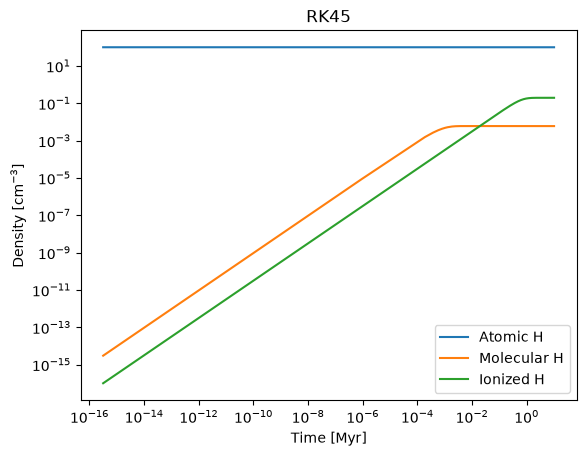

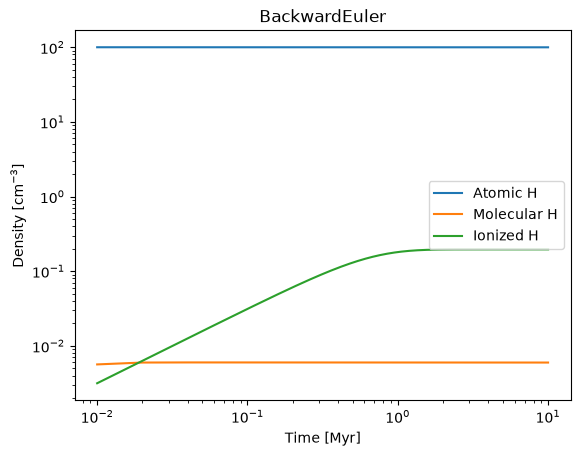

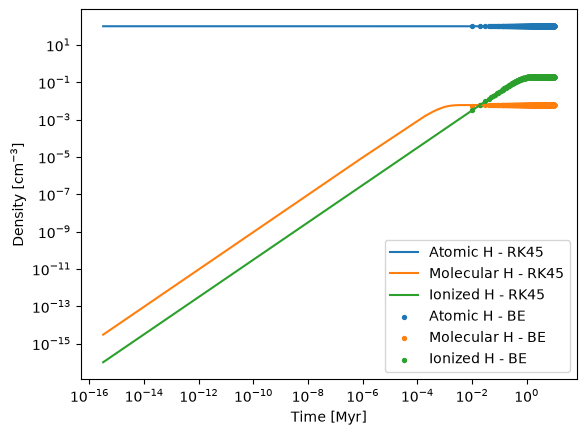

Minimum steps: 11
Relative errors: [1.51221061e-09 3.37301172e-07 7.49700868e-07]


In [10]:
## And define my initial conditions, let's start with 100 H atoms per cm^-3
y0 = np.array([100.0, 0.0, 0.0])

t_rk, Y_rk = ode_adaptivestep(
    dydt,
    0,
    y0,
    1e7 * 365.25 * 24 * 60 * 60,
    1e-6,
    0.01
)

time_myr = t_rk / (1e6 * 365.25 * 24 * 60 * 60)

plt.loglog(time_myr[1:], Y_rk[1:,0], label="Atomic H")
plt.loglog(time_myr[1:], Y_rk[1:,1], label="Molecular H")
plt.loglog(time_myr[1:], Y_rk[1:,2], label="Ionized H")

plt.xlabel("Time [Myr]")
plt.ylabel(r"Density [cm$^{-3}$]")
plt.title("RK45")
plt.legend()
plt.show()

t_be, Y_be = ode_backwardeuler(
    1000,
    dydt,
    jacobian,
    0,
    y0,
    1e7 * 365.25 * 24 * 60 * 60
)

time_myr = t_be / (1e6 * 365.25 * 24 * 60 * 60)

plt.loglog(time_myr[1:], Y_be[1:,0], label="Atomic H")
plt.loglog(time_myr[1:], Y_be[1:,1], label="Molecular H")
plt.loglog(time_myr[1:], Y_be[1:,2], label="Ionized H")

plt.xlabel("Time [Myr]")
plt.ylabel(r"Density [cm$^{-3}$]")
plt.title("BackwardEuler")
plt.legend()
plt.show()

time_rk = t_rk / (1e6 * 365.25 * 24 * 60 * 60)
time_be = t_be / (1e6 * 365.25 * 24 * 60 * 60)

plt.loglog(time_rk[1:], Y_rk[1:,0], label="Atomic H - RK45")
plt.loglog(time_rk[1:], Y_rk[1:,1], label="Molecular H - RK45")
plt.loglog(time_rk[1:], Y_rk[1:,2], label="Ionized H - RK45")

plt.scatter(time_be[1:], Y_be[1:,0], s=8, label="Atomic H - BE")
plt.scatter(time_be[1:], Y_be[1:,1], s=8, label="Molecular H - BE")
plt.scatter(time_be[1:], Y_be[1:,2], s=8, label="Ionized H - BE")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Time [Myr]")
plt.ylabel(r"Density [cm$^{-3}$]")
plt.legend()
plt.show()

x1 = 1e7 * 365.25 * 24 * 60 * 60

for nstep in range(1, 1001):

    t_be, Y_be = ode_backwardeuler(
        nstep,
        dydt,
        jacobian,
        0,
        y0,
        x1
    )

    relative_error = np.abs(
        (Y_be[-1] - Y_rk[-1]) / Y_rk[-1]
    )

    if np.max(relative_error) < 1e-6:
        print("Minimum steps:", nstep)
        print("Relative errors:", relative_error)
        break